In [11]:
from solver import *
from consts import *
from genetic_algo import fitness_function

In [12]:
from pathlib import Path
import aerosandbox as asb


# Lista dostępnych profilów (załadowana raz na starcie)
def load_airfoils(folder):
    files = list(folder.glob("*.dat"))
    return {i: asb.Airfoil(name=f.stem, coordinates=f) for i, f in enumerate(files)}

AIRFOIL_DATABASE = load_airfoils(AIRFOIL_FOLDER)
AIRFOIL_DATABASE

{0: Airfoil AG25-il (160 points),
 1: Airfoil AG35 (180 points),
 2: Airfoil AG36 (180 points),
 3: Airfoil AH 79-100 A (97 points),
 4: Airfoil bumblebee fuselage 134 (157 points),
 5: Airfoil BumbleBee fuselage 178 (157 points),
 6: Airfoil FX 60-100 (97 points),
 7: Airfoil GOE 444 (33 points),
 8: Airfoil NACA-0009 smoothed (69 points),
 9: Airfoil RG-15 8.9% (62 points),
 10: Airfoil Roncz Marske-7 low drag flw (71 points),
 11: Airfoil S7012 8.75% (81 points),
 12: Airfoil SD8020-010-88 (61 points)}

In [13]:
asb.__version__

'4.2.9'

In [14]:
print(AIRFOIL_DATABASE)
print("Rozpiętość: ", B)
print("Prędkość przelotowa: ", TARGET_VELOCITY, "m/s")
print("Masa elektroniki i baterii: ", FIXED_MASS, "kg")
print("Gęstość struktury skrzydła: ", WING_DENSITY, "kg/m2")

{0: Airfoil AG25-il (160 points), 1: Airfoil AG35 (180 points), 2: Airfoil AG36 (180 points), 3: Airfoil AH 79-100 A (97 points), 4: Airfoil bumblebee fuselage 134 (157 points), 5: Airfoil BumbleBee fuselage 178 (157 points), 6: Airfoil FX 60-100 (97 points), 7: Airfoil GOE 444 (33 points), 8: Airfoil NACA-0009 smoothed (69 points), 9: Airfoil RG-15 8.9% (62 points), 10: Airfoil Roncz Marske-7 low drag flw (71 points), 11: Airfoil S7012 8.75% (81 points), 12: Airfoil SD8020-010-88 (61 points)}
Rozpiętość:  1.2
Prędkość przelotowa:  20.0 m/s
Masa elektroniki i baterii:  0.4 kg
Gęstość struktury skrzydła:  2 kg/m2


In [21]:
test_genes ={
        "y_root": 0.09,
        "y_break1_f": 0.2,
        "y_break2_f": 0.420549670268315,
        "y_tip_f": 0.7337033183025055,
        "c_root": 0.25,
        "c_brk1": 0.15,
        "c_brk2": 0.08971753286476476,
        "c_tip": 0.04322395957638015,
        "t_root": -0.9100582160077232,
        "t_brk1": -1.7072620316717013,
        "t_brk2": -0.481745609128977,
        "t_tip": -1.9791666325114614,
        "x_root": 0.03237276132966136,
        "x_brk1": 0.21173791910087347,
        "x_brk2": 0.3713831678291586,
        "x_tip": 0.45,
        "z_root": 0,
        "z_brk1":0,
        "z_brk2": 0,
        "z_tip": 0.0,
        "winglet_target_angle": 83.86078782481704,
        "h_w": 0.08639819927006795,
        "R_w": 0.1,
        "c_w_end": 0.09,
        "sweep_w": 0.08835201447553444,
        "toe": -1.504438474032983,
        "id_root": 10.888313177191632,
        "id_brk1": 5.831164430626787,
        "id_brk2": 7.4661891929543085,
        "id_tip": 6.146332695055493,
        "id_w": 9.075189360727641
        
}

airplane, mass = build_airplane_curved(test_genes, 'quadratic')
#score, details = fitness_function(test_genes)
print(f"Samolot zbudowany pomyślnie! Szacowana masa: {mass:.3f} kg")
airplane.draw(backend='plotly')
alphas = np.linspace(-5, 15, 30)
x_cg = get_cg(airplane, sm=0.1)
data, x_cg_target = GA_aerodynamics(airplane, TARGET_VELOCITY, alphas, xyz_ref_orig=[x_cg, 0, 0])
score, score_details = fitness_function_weighted(data)
print(f"Score: {score:.2f}")
print(data)
s = str(x_cg_target)
print(f"Środek ciężkości: {s} m")



Samolot zbudowany pomyślnie! Szacowana masa: 0.752 kg


Score: 1.14
{'ld': np.float64(6.362168792241973), 'cl': np.float64(0.12977700213586435), 'cd': np.float64(0.020398233114172385), 'cm_cg': -0.02180888659395767, 'cma': np.float64(-0.7279499164991288), 'cnb': np.float64(0.08083736621517341), 'oswald': np.float64(0.8893355959851803), 'cmq': np.float64(-7.781860924072785), 'clp': np.float64(-0.5002351120658305), 'cnr': np.float64(-0.04487389341608518), 'alpha': 1.0, 'alpha_in_range': False, 'trim_fallback': True, 'mass': np.float64(0.3521794043976894), 'x_np': np.float64(0.2648131209263092), 'x_cg': array([0.24602103]), 'x_cg_ref': array([0.24602103])}
Środek ciężkości: [0.24602103] m


In [22]:
results = analyze_aerodynamics(airplane, mass, TARGET_VELOCITY)
print(results)



{'ld': np.float64(11.129951383873927), 'sm': 0.08, 'cnb': np.float64(0.14589197306785173), 'cl': np.float64(0.2499868012661705), 'cd': np.float64(0.022460727153613073), 'cm_cg': np.float64(-0.030800519685485195), 'mass': np.float64(0.7521794043976895), 'x_np': array([0.26348195]), 'x_cg': array([0.24894093]), 'obj': AeroBuildup(
	airplane=Airplane 'Untitled' (1 wing, 0 fuselages)
	op_point=OperatingPoint instance:
	State variables:
		atmosphere: Atmosphere (altitude: 0 m (0 ft), method: 'differentiable')                                                             
		  velocity: 20.0                                                                                                                    
		     alpha: 2.0                                                                                                                     
		      beta: 1.0                                                                                                                     
		         p: 0.0       

In [23]:
metrics = calculate_extra_metrics(airplane, mass, TARGET_VELOCITY)
print(f"--- GEOMETRIA ---")
print(f"Powierzchnia: {metrics['S [m^2]']:.3f} m2")
print(f"Rozpiętość: {metrics['Span']:.3f} m")
print(f"Aerodynamic Center: {metrics['Aerodynamic center']}")
print(f"Neutral Point: ", results['x_np'])
print(f"AR: {metrics['AR']:.2f} (Efektywne: {metrics['AR_eff']:.2f})")
print(f"Taper Ratio: {metrics['Taper']:.2f}")
print(f"Oswald efficiency: {metrics['e']:.3f}")
print(f"Obciążenie: {metrics['Wing Loading [kg/m^2]']:.2f} kg/m2")
print(f"Re: {metrics['Re']:.0f}")
print(f"Mean Twist Angle: {metrics['MtA']:.2f} deg")
print(f"Mean Sweep Angle: {metrics['MsA']:.2f} deg")
print(f"Mean Dihedral Angle: {metrics['MdA']:.2f} deg")

--- GEOMETRIA ---
Powierzchnia: 0.176 m2
Rozpiętość: 1.365 m
Aerodynamic Center: [0.24885246 0.         0.00415936]
Neutral Point:  [0.26348195]
AR: 10.59 (Efektywne: 10.59)
Taper Ratio: 0.26
Oswald efficiency: 0.701
Obciążenie: 4.27 kg/m2
Re: 246033
Mean Twist Angle: -0.95 deg
Mean Sweep Angle: 36.38 deg
Mean Dihedral Angle: 7.99 deg


In [18]:
'''alphas = np.linspace(-5, 12, 30)

basic_aoa = basic_analysis(
    airplane=airplane,
    velocity=18,
    alphas=alphas
)'''

'alphas = np.linspace(-5, 12, 30)\n\nbasic_aoa = basic_analysis(\n    airplane=airplane,\n    velocity=18,\n    alphas=alphas\n)'

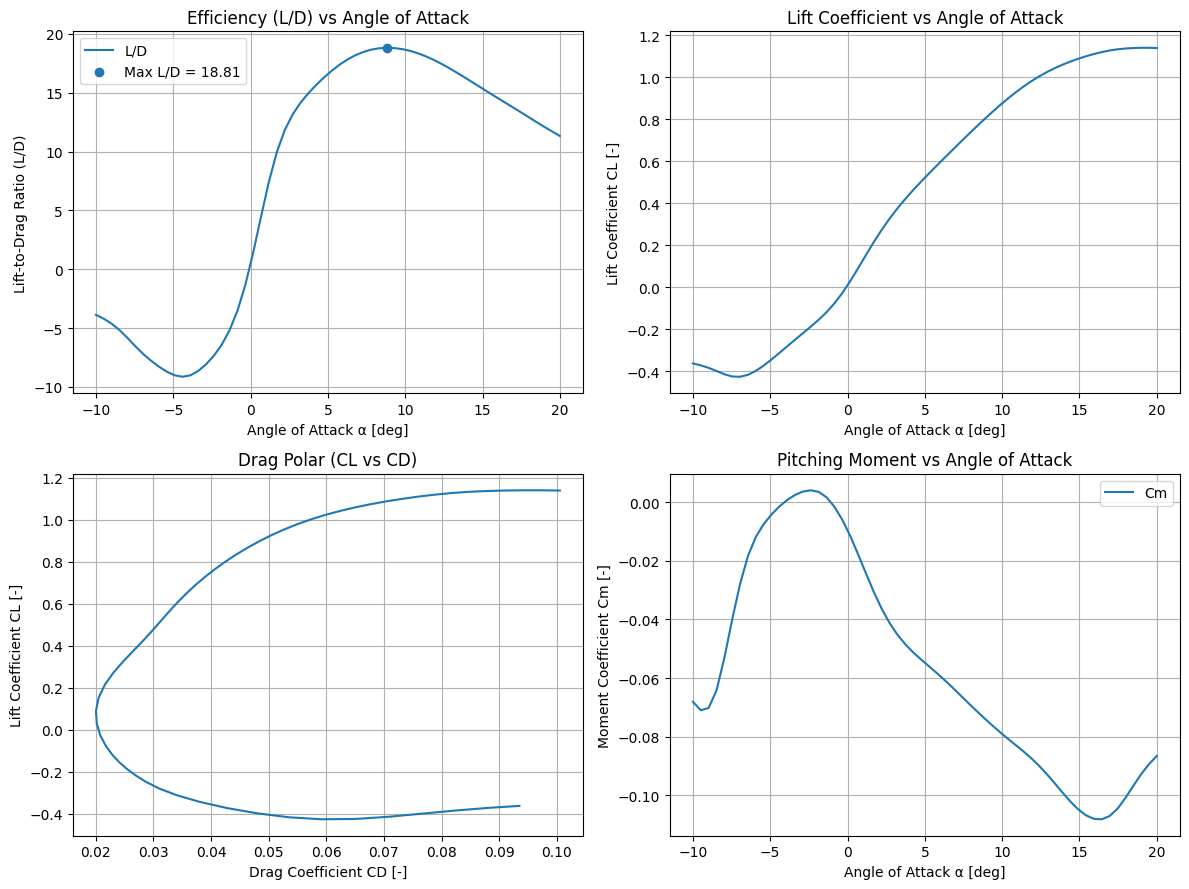


=== SUMMARY ===
Max L/D       : 18.81 at α = 8.81 deg
Oswald e      : 0.791


{'F_g': [array([  1.26115774,   1.11294911,   0.94546415,   0.75445458,
           0.55703138,   0.40055867,   0.31225535,   0.28301216,
           0.29039524,   0.32023298,   0.36886144,   0.43520375,
           0.51690587,   0.60571411,   0.69016441,   0.76319412,
           0.8223815 ,   0.86575158,   0.88984642,   0.89107136,
           0.86743567,   0.81917086,   0.74859253,   0.65728992,
           0.54367012,   0.40381795,   0.23384009,   0.03168368,
          -0.20242128,  -0.46668228,  -0.75885139,  -1.0770143 ,
          -1.41979788,  -1.78615208,  -2.17501376,  -2.58508477,
          -3.01478203,  -3.46222933,  -3.92515762,  -4.40080657,
          -4.88589709,  -5.37665099,  -5.86897405,  -6.35885136,
          -6.84284032,  -7.31855427,  -7.78494987,  -8.24206472,
          -8.69029882,  -9.12991967,  -9.56096752,  -9.98295569,
         -10.3939335 , -10.78923838, -11.16228964, -11.5102243 ,
         -11.83719511, -12.14786772, -12.44245186, -12.71456933]),
  array([0., 0.,

In [24]:
alphaSweep = analyze_alpha_sweep_and_plot(airplane, TARGET_VELOCITY, np.linspace(-10, 20, 60), [x_cg_target, 0 ,0])
alphaSweep['raw_result']


In [20]:
print(alphaSweep['raw_result']['wing_aero_components'][0].oswalds_efficiency)
print(f"keys: {list(alphaSweep['raw_result'].keys())}")
res = alphaSweep['raw_result']
print(f"Neutral point: {res['x_np']}")
print(alphaSweep['raw_result']['wing_aero_components'][0].keys())
print(f"center of gravity: {res['x_cg']}")
#alphaSweep['raw_result']['Clb']

0.8141086542667971
keys: ['F_g', 'M_g', 'F_b', 'F_w', 'M_b', 'M_w', 'L', 'Y', 'D', 'l_b', 'm_b', 'n_b', 'CL', 'CY', 'CD', 'Cl', 'Cm', 'Cn', 'wing_aero_components', 'fuselage_aero_components', 'D_profile', 'D_induced', 'CLa', 'CDa', 'CYa', 'Cla', 'Cma', 'Cna', 'x_np', 'CLb', 'CDb', 'CYb', 'Clb', 'Cmb', 'Cnb', 'x_np_lateral', 'CLp', 'CDp', 'CYp', 'Clp', 'Cmp', 'Cnp', 'CLq', 'CDq', 'CYq', 'Clq', 'Cmq', 'Cnq', 'CLr', 'CDr', 'CYr', 'Clr', 'Cmr', 'Cnr']
Neutral point: [ 1.65393817e-01  2.40426411e-01  3.06738792e-01  3.67064173e-01
  4.37260979e-01  7.12414446e-01 -1.69938936e-01  1.47918314e-01
  2.04793036e-01  2.23669352e-01  2.30731659e-01  2.34398562e-01
  2.37191000e-01  2.39929914e-01  2.43284426e-01  2.47980022e-01
  2.53734309e-01  2.59169484e-01  2.62665737e-01  2.64287046e-01
  2.65377199e-01  2.65937347e-01  2.65828630e-01  2.65155493e-01
  2.63870804e-01  2.62147496e-01  2.60297983e-01  2.58617947e-01
  2.57372291e-01  2.56730569e-01  2.56695153e-01  2.57101731e-01
  2.57683737e

AttributeError: 'AeroComponentResults' object has no attribute 'keys'

In [ ]:
alphaSweep['raw_result']['x_np']

array([0.16056145, 0.14868166, 0.1446031 , 0.14779183, 0.157595  ,
       0.17139713, 0.18855426, 0.21130246, 0.22985084, 0.24264865,
       0.25209107, 0.25946404, 0.26544103, 0.2700548 , 0.27345573,
       0.27633883, 0.27891284, 0.28084569, 0.28198684, 0.28257558,
       0.28291541, 0.28340037, 0.28481216, 0.28690083, 0.28824676,
       0.28794957, 0.28609504, 0.28320133, 0.27978867, 0.27628964,
       0.27307142, 0.27042409, 0.2685222 , 0.26740836, 0.26701845,
       0.26723344, 0.26793285, 0.2690337 , 0.2705023 , 0.27231291,
       0.27433563, 0.27625257, 0.27770954, 0.27860782, 0.27910258,
       0.27934015, 0.27934984, 0.27911664, 0.27863332, 0.27789663,
       0.2768973 , 0.27562616, 0.27410098, 0.27239671, 0.27065116,
       0.26905035, 0.26782996, 0.26731756, 0.26801534, 0.27074218])

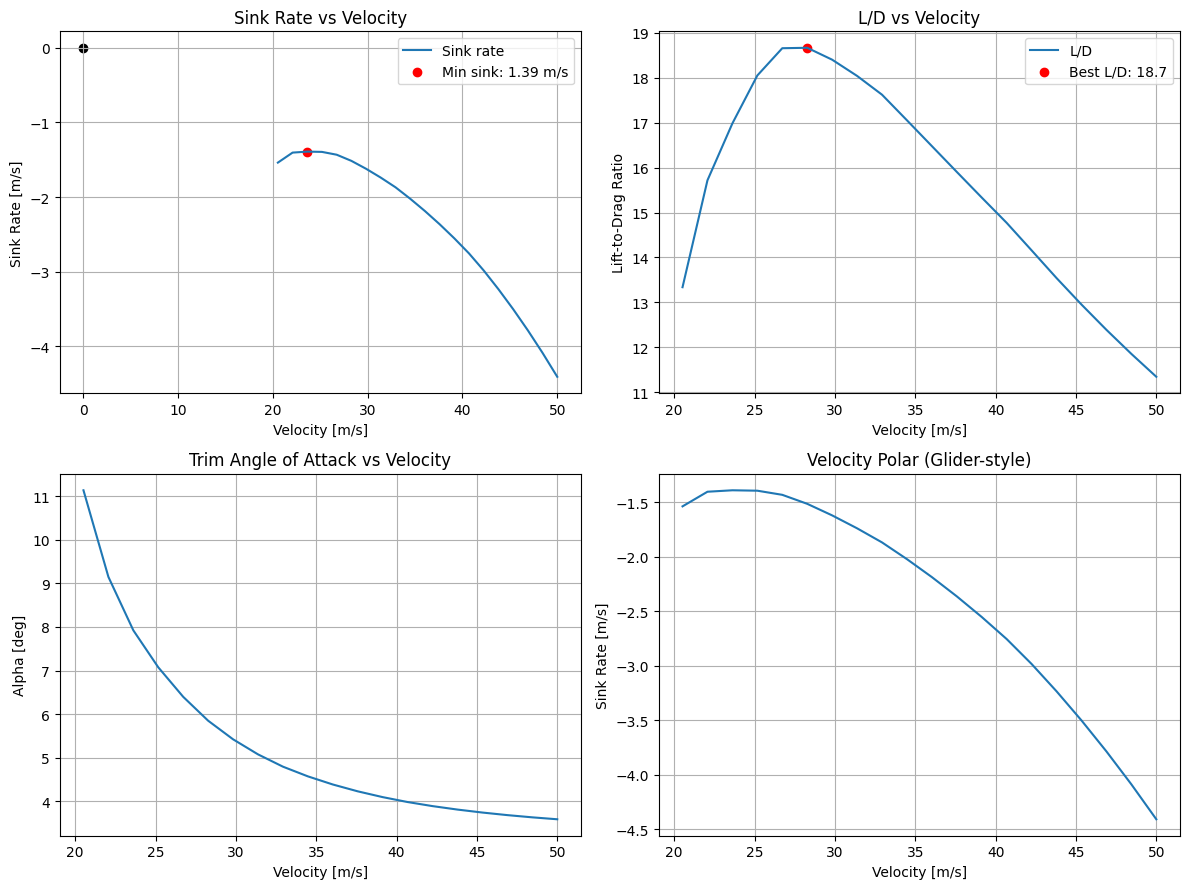


=== VELOCITY POLAR SUMMARY ===
Min sink speed   : 23.62 m/s
Min sink rate    : 1.39 m/s
Best glide speed : 28.28 m/s
Max L/D          : 18.67


In [ ]:
import numpy as np
velocities = np.linspace(5, 50, 30)

polar = analyze_velocity_polar(
    airplane=airplane,
    mass=5,
    velocities=velocities
)

In [ ]:
op = asb.OperatingPoint(velocity=TARGET_VELOCITY, alpha=2)
ab = asb.AeroBuildup(  # This sets up the analysis, but doesn't execute calculation
    airplane=airplane,  # type: asb.Airplane
    op_point=op,  # type: asb.OperatingPoint
    xyz_ref=[results['x_cg'], 0, 0],  # Moment reference and center of rotation.
)
aero = ab.run()  # This executes the actual aero analysis.
aero_with_stability_derivs = ab.run_with_stability_derivatives() 